# Exploratory Analysis of Olist’s Brazilian E-Commerce Platform

This project uses exploratory data analysis (EDA) to study an e-commerce dataset and understand customer behavior, sales results, and how the platform operates.

# Dataset

The dataset used in this project comes from the Brazilian e-commerce public dataset on Kaggle, which contains detailed records of orders placed through the Olist marketplace

# Database Schema

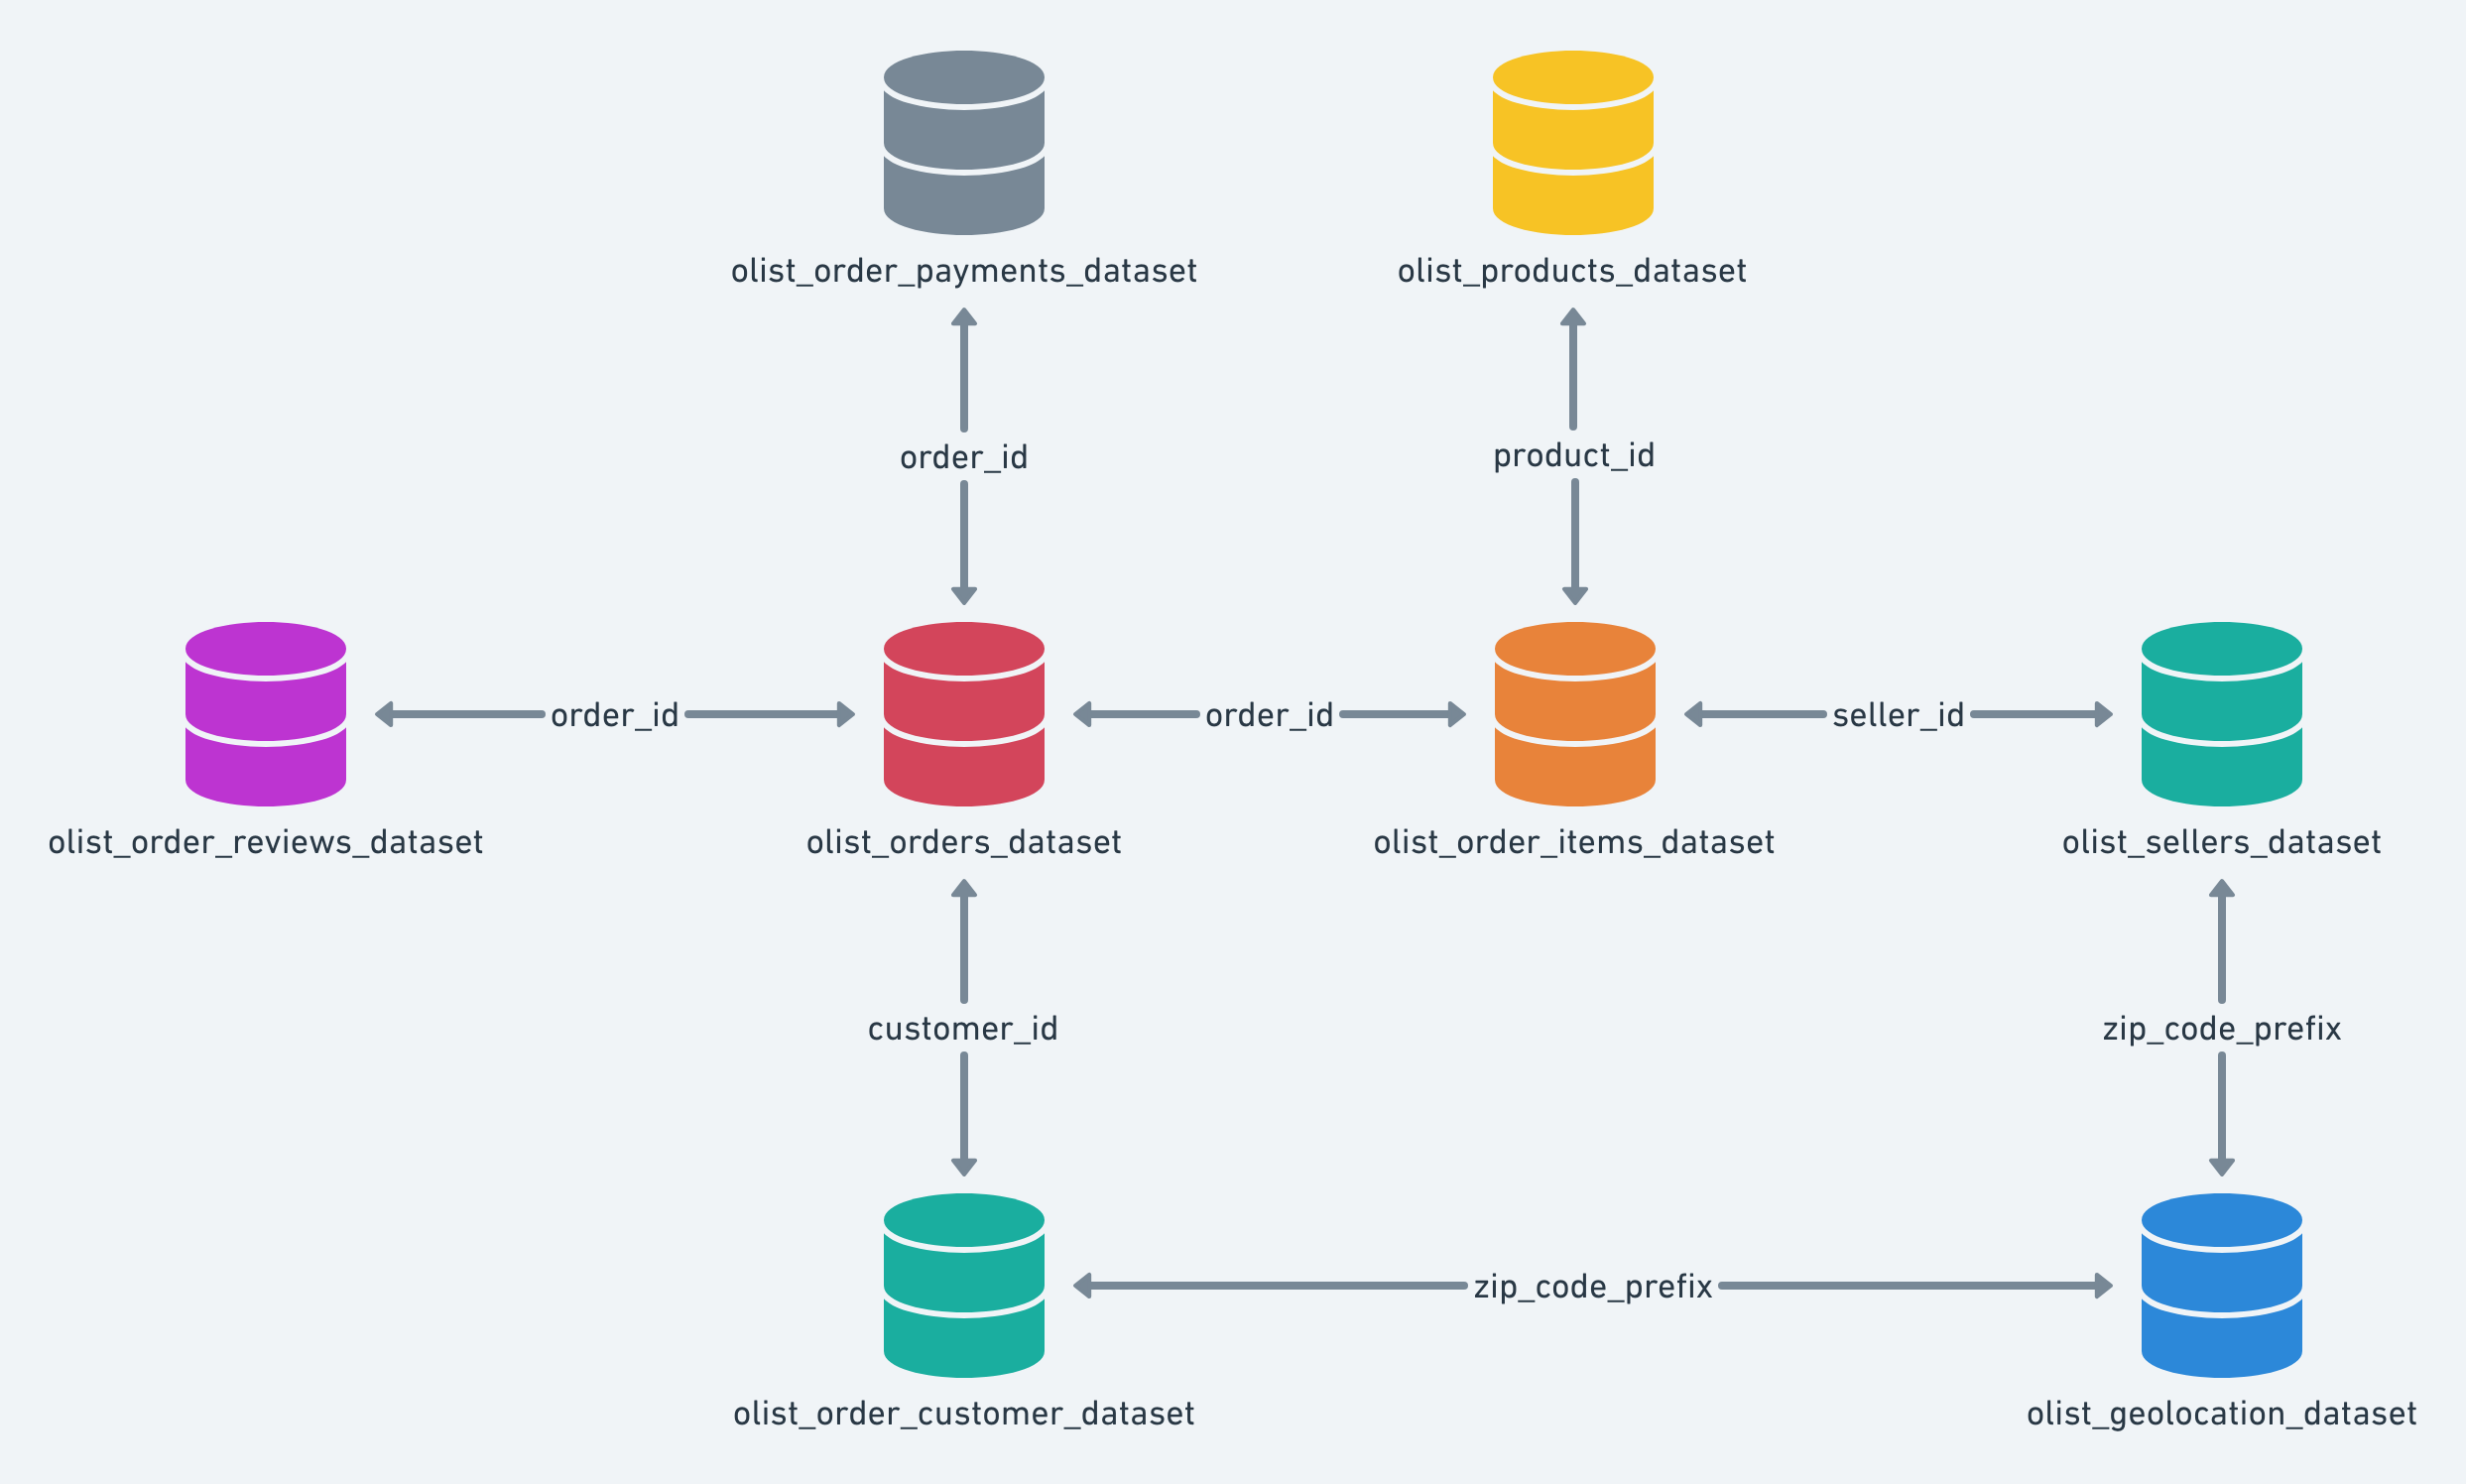

In the MySQL database used for this analysis, the _dataset suffix was removed for simplicity, while the table relationships remain unchanged. 

There's also a product_category_name_translation table included in the database to translate product category names into English.

# Libraries

In [1]:
#Standard libs
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker

#MySQL Database Connection
from sqlalchemy import create_engine
engine = create_engine("") # connection credentials not included


# Exploratory Data Analysis

## Query 1 - Monthly Order Volume 

In [2]:
query1 = """
WITH
order_2016 AS
(
    SELECT
        MONTH(order_purchase_timestamp) AS order_month,
        COUNT(order_id) AS `2016`
    FROM olist_orders
    WHERE YEAR(order_purchase_timestamp) = 2016 
      AND order_approved_at IS NOT NULL
    GROUP BY order_month
),

order_2017 AS
(
    SELECT
        MONTH(order_purchase_timestamp) AS order_month,
        COUNT(order_id) AS `2017`
    FROM olist_orders
    WHERE YEAR(order_purchase_timestamp) = 2017 
      AND order_approved_at IS NOT NULL
    GROUP BY order_month
),

order_2018 AS
(
    SELECT
        MONTH(order_purchase_timestamp) AS order_month,
        COUNT(order_id) AS `2018`
    FROM olist_orders
    WHERE YEAR(order_purchase_timestamp) = 2018 
      AND order_approved_at IS NOT NULL
    GROUP BY order_month
)

SELECT
    CASE 
        WHEN b.order_month = 1  THEN 'Jan'
        WHEN b.order_month = 2  THEN 'Feb'
        WHEN b.order_month = 3  THEN 'Mar'
        WHEN b.order_month = 4  THEN 'Apr'
        WHEN b.order_month = 5  THEN 'May'
        WHEN b.order_month = 6  THEN 'Jun'
        WHEN b.order_month = 7  THEN 'Jul'
        WHEN b.order_month = 8  THEN 'Aug'
        WHEN b.order_month = 9  THEN 'Sep'
        WHEN b.order_month = 10 THEN 'Oct'
        WHEN b.order_month = 11 THEN 'Nov'
        WHEN b.order_month = 12 THEN 'Dec'
    END AS month,
    COALESCE(a.`2016`,0) AS `2016`,
    COALESCE(b.`2017`,0) AS `2017`,
    COALESCE(c.`2018`,0) AS `2018`
FROM order_2017 b
LEFT JOIN order_2016 a ON a.order_month = b.order_month
LEFT JOIN order_2018 c ON b.order_month = c.order_month
ORDER BY b.order_month;
"""
df = pd.read_sql(query1, engine)
display(df)


,month,2016,2017,2018
0,Jan,0,797,7268
1,Feb,0,1766,6724
2,Mar,0,2680,7208
3,Apr,0,2400,6939
4,May,0,3691,6872
5,Jun,0,3241,6167
6,Jul,0,4021,6291
7,Aug,0,4325,6459
8,Sep,4,4281,1
9,Oct,318,4626,0


## Query 2 - Monthly Total Revenue 

In [3]:
query2 ="""
WITH 
payment_2016 AS
(
SELECT 
	table2016.month, 
	SUM(table2016.payment_value) AS order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2016
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2016
GROUP BY table2016.month
),

payment_2017 AS
(
SELECT 
	table2017.month, 
	SUM(table2017.payment_value) AS order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2017
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2017
GROUP BY table2017.month
),

payment_2018 AS
(
SELECT 
	table2018.month, 
	SUM(table2018.payment_value) AS order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2018 
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2018
GROUP BY table2018.month
)

SELECT 
CASE
	WHEN b.month = 1 then 'Jan'
    WHEN b.month = 2 then 'Feb'
    WHEN b.month = 3 then 'Mar'
    WHEN b.month = 4 then 'Apr'
    WHEN b.month = 5 then 'May'
    WHEN b.month = 6 then 'Jun'
    WHEN b.month = 7 then 'Jul'
    WHEN b.month = 8 then 'Aug'
    WHEN b.month = 9 then 'Sep'
    WHEN b.month = 10 then 'Oct'
    WHEN b.month = 11 then 'Nov'
    WHEN b.month = 12 then 'Dec'
END AS Month,
COALESCE(ROUND(a.order_value,0), 0) AS '2016',
COALESCE(ROUND(b.order_value,0), 0) AS '2017',
COALESCE(ROUND(c.order_value,0), 0) AS '2018'
FROM payment_2016 a
RIGHT JOIN payment_2017 b ON a.month = b.month
LEFT JOIN payment_2018 c ON b.month = c.month
ORDER BY b.month ASC;
"""
df = pd.read_sql(query2, engine)
df

,Month,2016,2017,2018
0,Jan,0.0,138488.0,1115004.0
1,Feb,0.0,291908.0,992463.0
2,Mar,0.0,449864.0,1159652.0
3,Apr,0.0,417788.0,1160785.0
4,May,0.0,592919.0,1153982.0
5,Jun,0.0,511276.0,1023881.0
6,Jul,0.0,592383.0,1066541.0
7,Aug,0.0,674396.0,1022425.0
8,Sep,252.0,727762.0,4440.0
9,Oct,59090.0,779678.0,590.0


## Query 3 - Monthly Average Order Value

In [4]:
query3 = """
WITH 
payment_2016 AS
(
SELECT 
	table2016.month, 
	(SUM(table2016.payment_value)/COUNT(table2016.order_id)) AS average_order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2016
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2016
GROUP BY table2016.month
),

payment_2017 AS
(
SELECT 
	table2017.month, 
	(SUM(table2017.payment_value)/COUNT(table2017.order_id)) AS average_order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2017
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2017
GROUP BY table2017.month
),

payment_2018 AS
(
SELECT 
	table2018.month, 
	(SUM(table2018.payment_value)/COUNT(table2018.order_id)) AS average_order_value
FROM
	(SELECT 
	a.order_id, 
	MONTH(b.order_purchase_timestamp) month,
	SUM(a.payment_value) payment_value
	FROM olist_order_payments a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	WHERE YEAR(b.order_purchase_timestamp) = 2018 
	GROUP BY a.order_id
    HAVING SUM(a.payment_value) > 0 OR SUM(a.payment_type = 'voucher')) AS table2018
GROUP BY table2018.month
)

SELECT 
CASE
	WHEN b.month = 1 then 'Jan'
    WHEN b.month = 2 then 'Feb'
    WHEN b.month = 3 then 'Mar'
    WHEN b.month = 4 then 'Apr'
    WHEN b.month = 5 then 'May'
    WHEN b.month = 6 then 'Jun'
    WHEN b.month = 7 then 'Jul'
    WHEN b.month = 8 then 'Aug'
    WHEN b.month = 9 then 'Sep'
    WHEN b.month = 10 then 'Oct'
    WHEN b.month = 11 then 'Nov'
    WHEN b.month = 12 then 'Dec'
END AS Month,
COALESCE(ROUND(a.average_order_value,2),0) AS '2016',
COALESCE(ROUND(b.average_order_value,2),0) AS '2017',
COALESCE(ROUND(c.average_order_value,2),0) AS '2018'
FROM payment_2016 a
RIGHT JOIN payment_2017 b ON a.month = b.month
LEFT JOIN payment_2018 c ON b.month = c.month
ORDER BY b.month ASC;
"""
df = pd.read_sql(query3, engine)
df

,Month,2016,2017,2018
0,Jan,0.00,173.11,153.39
1,Feb,0.00,163.99,147.51
2,Mar,0.00,167.73,160.82
3,Apr,0.00,173.79,167.28
4,May,0.00,160.25,167.90
5,Jun,0.00,157.56,166.03
6,Jul,0.00,147.14,169.51
7,Aug,0.00,155.71,157.05
8,Sep,84.08,169.84,295.97
9,Oct,182.38,168.36,147.42


## Query 4 - Revenue by City

,state,city,revenue,revenue_pct
0,SP,Sao Paulo,2203373.0,13.76%
1,RJ,Rio De Janeiro,1161927.0,7.26%
2,MG,Belo Horizonte,421765.0,2.63%
3,DF,Brasilia,354217.0,2.21%
4,PR,Curitiba,247392.0,1.55%
5,RS,Porto Alegre,224731.0,1.40%
6,BA,Salvador,218072.0,1.36%
7,SP,Campinas,216248.0,1.35%
8,SP,Guarulhos,165122.0,1.03%
9,RJ,Niteroi,139997.0,0.87%


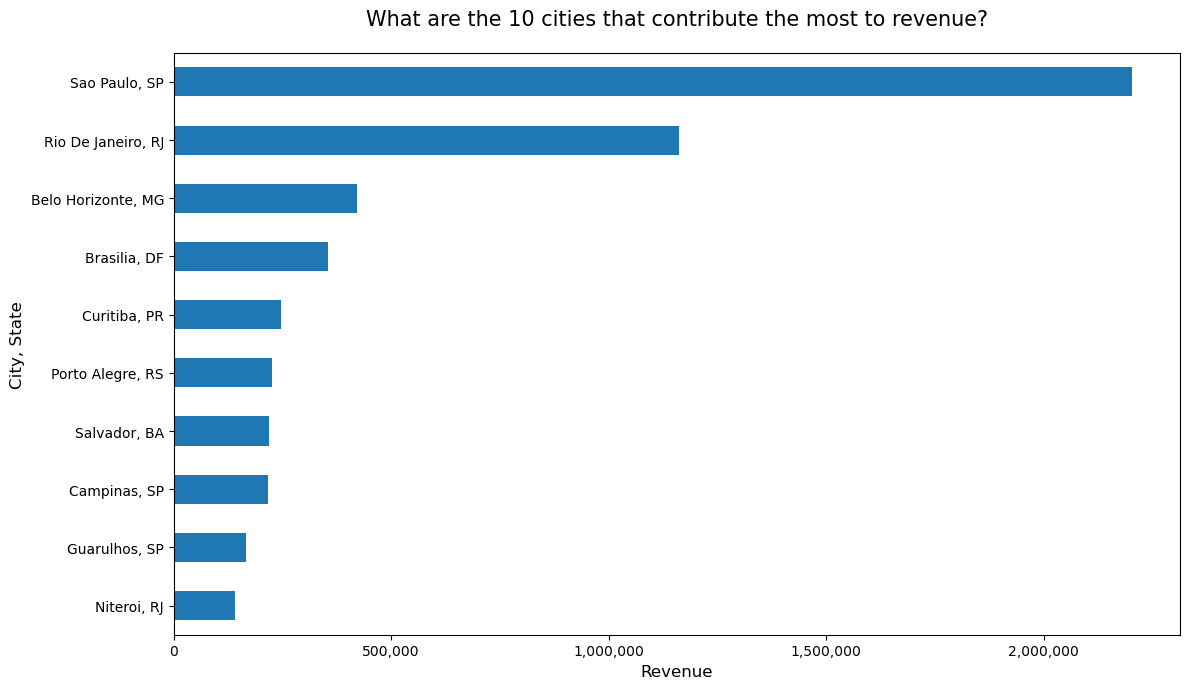

In [5]:
query4 = """
SELECT  
	d.customer_state state,
    d.customer_city city,
	ROUND(SUM(d.revenue)) revenue,
    CONCAT(ROUND((SUM(d.revenue)*100/(SUM(SUM(d.revenue)) OVER())),2),'%%') AS revenue_pct
FROM
	(SELECT 
		a.*,
		c.customer_city,
		c.customer_state
	FROM
		(SELECT
			 a.order_id,
			 SUM(a.payment_value) AS revenue
		FROM 
			olist_order_payments a
		GROUP BY a.order_id
		ORDER BY revenue) AS a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	LEFT JOIN olist_customers c ON b.customer_id = c.customer_id) AS d
GROUP BY state, city
ORDER BY revenue DESC;
"""
df = pd.read_sql(query4, engine)
df['city'] = df['city'].str.title()

display(df.head(20))
df['city_state'] = df['city'] + ", " + df['state']

df_top10 = df.head(10)
plot=df_top10.sort_values('revenue', ascending=True).plot(
    x='city_state', 
    y='revenue', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('What are the 10 cities that contribute the most to revenue?', fontsize=15, pad=20)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('City, State', fontsize=12)

plt.tight_layout()
plt.show()


## Query 5 - Revenue by State

,state,revenue,revenue_pct
0,SP,5998227.0,37.47%
1,RJ,2144380.0,13.39%
2,MG,1872257.0,11.70%
3,RS,890899.0,5.57%
4,PR,811156.0,5.07%
5,SC,623086.0,3.89%
6,BA,616646.0,3.85%
7,DF,355141.0,2.22%
8,GO,350092.0,2.19%
9,ES,325968.0,2.04%


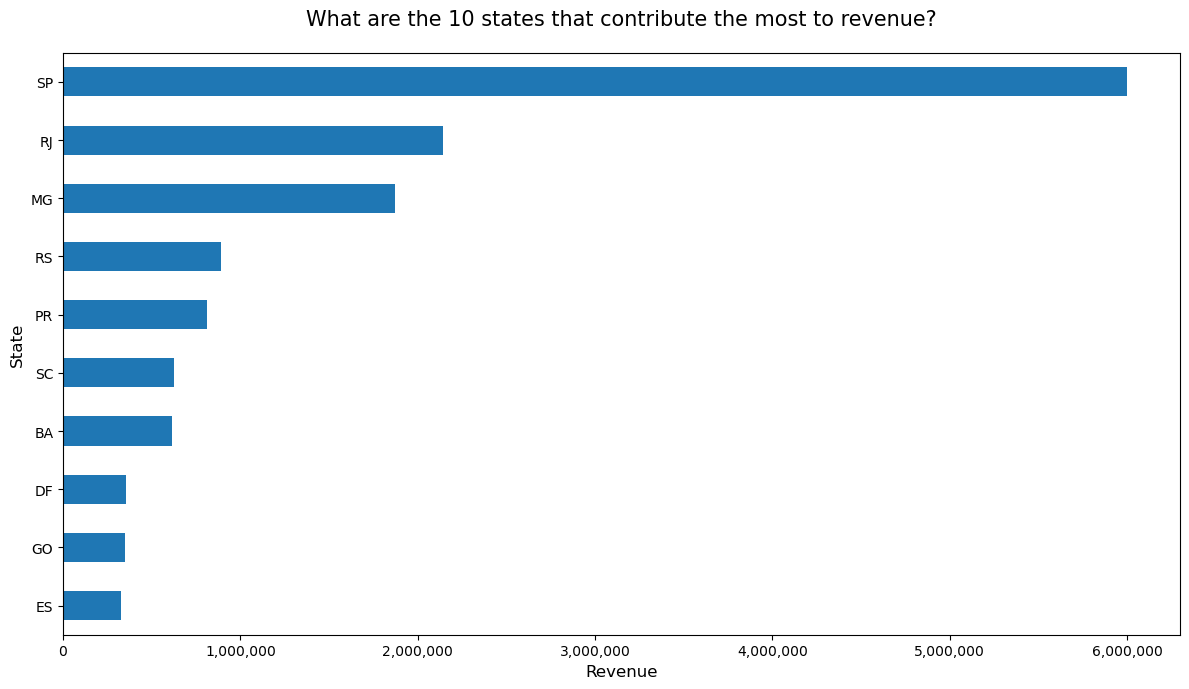

In [6]:
query5 = """
SELECT  
	d.customer_state state, 
	ROUND(SUM(d.revenue)) revenue,
    CONCAT(ROUND(SUM(d.revenue)*100/(SUM(SUM(d.revenue)) OVER()),2),'%%') as revenue_pct
FROM
	(SELECT 
		a.*,
		c.customer_city,
		c.customer_state
	FROM
		(SELECT
			 a.order_id,
			 SUM(a.payment_value) AS revenue
		FROM 
			olist_order_payments a
		GROUP BY a.order_id
		ORDER BY revenue) AS a
	LEFT JOIN olist_orders b ON a.order_id = b.order_id
	LEFT JOIN olist_customers c ON b.customer_id = c.customer_id) AS d
GROUP BY state
ORDER BY revenue DESC;
"""
df = pd.read_sql(query5,engine)
df.head(20)
display(df.head(20))

df_top10 = df.head(10)
plot=df_top10.sort_values('revenue', ascending=True).plot(
    x='state', 
    y='revenue', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('What are the 10 states that contribute the most to revenue?', fontsize=15, pad=20)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('State', fontsize=12)

plt.tight_layout()
plt.show(plot)

## Query 6 - Seller Distribution by State & City

In [7]:
query6_1 = """
SELECT 
    a.seller_state state,
    COUNT(a.seller_id) sellers,
    CONCAT(ROUND((COUNT(a.seller_id)*100/(SUM(COUNT(a.seller_id)) OVER())),2),'%%') AS sellers_pct
FROM olist_sellers a
GROUP BY state
ORDER BY sellers DESC;
"""
query6_2 = """
SELECT 
    a.seller_state state,
    a.seller_city city,
    COUNT(a.seller_id) sellers,
    CONCAT(ROUND((COUNT(a.seller_id)*100/(SUM(COUNT(a.seller_id)) OVER())),2),'%%') AS sellers_pct
FROM olist_sellers a
GROUP BY state, city
ORDER BY sellers DESC;
"""
df1 = pd.read_sql(query6_1,engine)
df2 = pd.read_sql(query6_2,engine)
df2['city'] = df2['city'].str.title()

### Query 6_1 - Seller Distribution by State

,state,sellers,sellers_pct
0,SP,1849,59.74%
1,PR,349,11.28%
2,MG,244,7.88%
3,SC,190,6.14%
4,RJ,171,5.53%
5,RS,129,4.17%
6,GO,40,1.29%
7,DF,30,0.97%
8,ES,23,0.74%
9,BA,19,0.61%


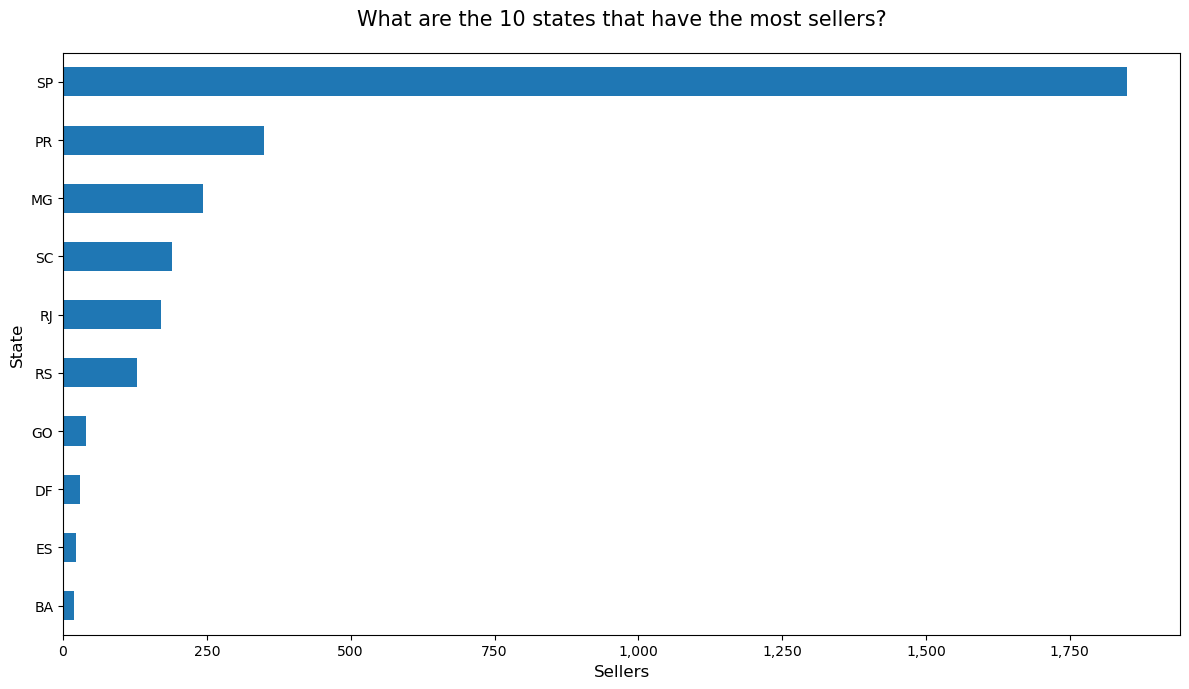

In [8]:
# Query6_1
display(df1.head(15))
df1_top10 = df1.head(10)
plot1=df1_top10.sort_values('sellers', ascending=True).plot(
    x='state', 
    y='sellers', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('What are the 10 states that have the most sellers?', fontsize=15, pad=20)
plt.xlabel('Sellers', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show(plot1)

### Query 6_2 - Seller Distribution by City

,state,city,sellers,sellers_pct
0,SP,Sao Paulo,695,22.46%
1,PR,Curitiba,124,4.01%
2,RJ,Rio De Janeiro,93,3.00%
3,MG,Belo Horizonte,66,2.13%
4,SP,Ribeirao Preto,52,1.68%
5,SP,Guarulhos,50,1.62%
6,SP,Ibitinga,49,1.58%
7,SP,Santo Andre,45,1.45%
8,SP,Campinas,41,1.32%
9,PR,Maringa,40,1.29%


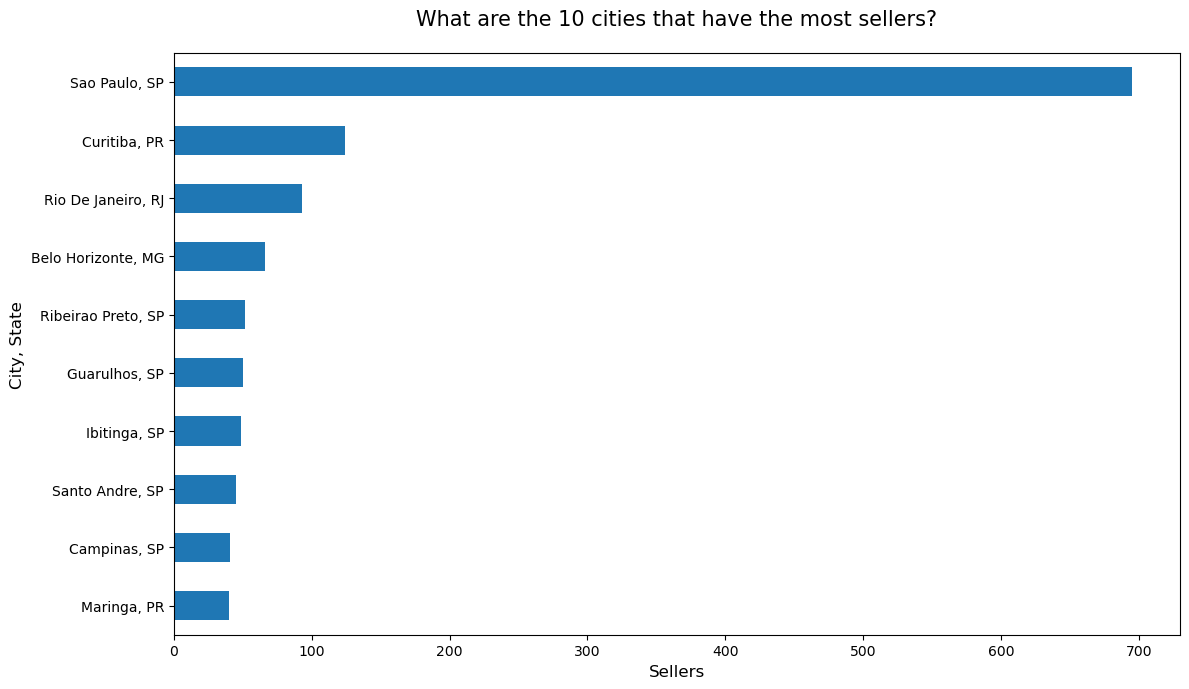

In [9]:
display(df2.head(15)) # Query6_2 
df2['city_state'] = df2['city'] + ", " + df2['state']
df2_top10 = df2.head(10)
plot2=df2_top10.sort_values('sellers', ascending=True).plot(
    x='city_state', 
    y='sellers', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('What are the 10 cities that have the most sellers?', fontsize=15, pad=20)
plt.xlabel('Sellers', fontsize=12)
plt.ylabel('City, State', fontsize=12)
plt.tight_layout()
plt.show(plot2)

## Query 7 - Customer Concentration by State & City

In [10]:
query7_1="""
SELECT
	a.customer_state AS state,
    COUNT(DISTINCT a.customer_unique_id) AS customers,
    CONCAT(ROUND((COUNT(DISTINCT a.customer_unique_id) * 100/(SUM(COUNT(DISTINCT a.customer_unique_id)) OVER())),2),'%%') AS customers_pct
FROM olist_customers a
GROUP BY a.customer_state
ORDER BY customers DESC;
"""
query7_2="""
SELECT
	a.customer_state AS state,
    a.customer_city AS city,
    COUNT(DISTINCT a.customer_unique_id) AS customers,
    CONCAT(ROUND((COUNT(DISTINCT a.customer_unique_id) * 100/(SUM(COUNT(DISTINCT a.customer_unique_id)) OVER())),2),'%%') AS customers_pct
FROM olist_customers a
GROUP BY a.customer_state, a.customer_city
ORDER BY customers DESC;
"""
df2=pd.read_sql(query7_2,engine)
df1=pd.read_sql(query7_1,engine)
df2['city'] = df2['city'].str.title()

### Query 7_1 - Customer Concentration by State 

,state,customers,customers_pct
0,SP,40302,41.92%
1,RJ,12384,12.88%
2,MG,11259,11.71%
3,RS,5277,5.49%
4,PR,4882,5.08%
5,SC,3534,3.68%
6,BA,3277,3.41%
7,DF,2075,2.16%
8,ES,1964,2.04%
9,GO,1952,2.03%


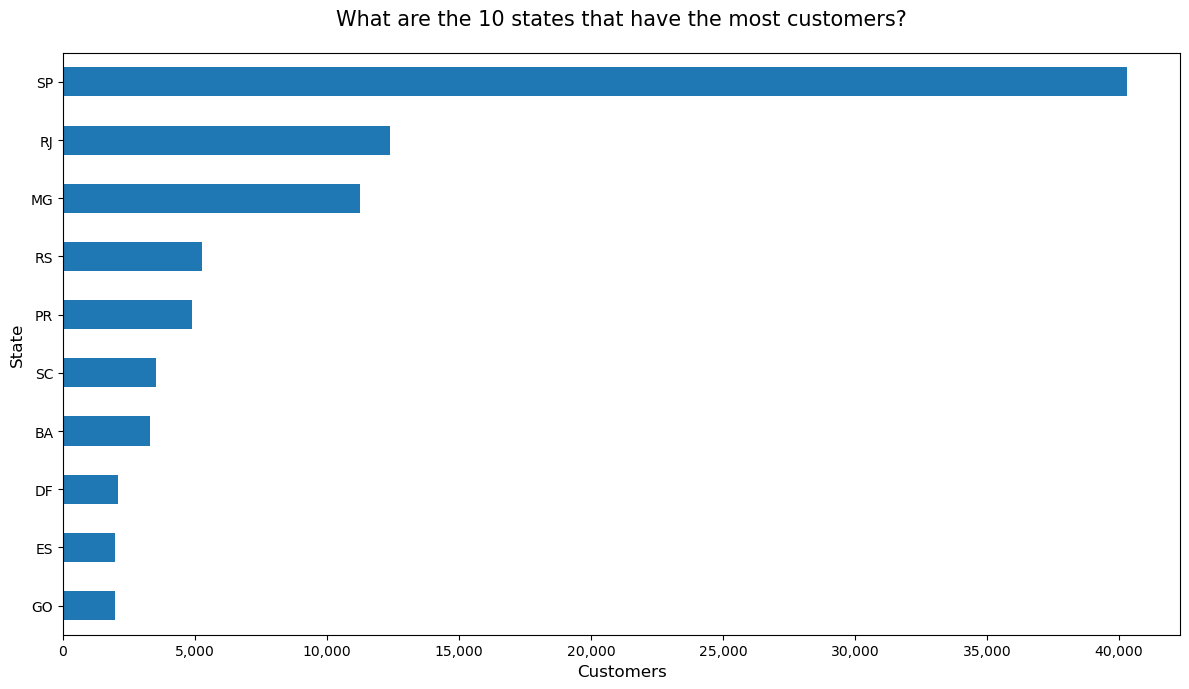

In [11]:
#query7_1
display(df1.head(15))
df1_top10 = df1.head(10)
plot1=df1_top10.sort_values('customers', ascending=True).plot(
    x='state', 
    y='customers', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('What are the 10 states that have the most customers?', fontsize=15, pad=20)
plt.xlabel('Customers', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show(plot1)

### Query 7_2 - Customer Concentration by City

,state,city,customers,customers_pct
0,SP,Sao Paulo,14984,15.57%
1,RJ,Rio De Janeiro,6620,6.88%
2,MG,Belo Horizonte,2672,2.78%
3,DF,Brasilia,2069,2.15%
4,PR,Curitiba,1465,1.52%
5,SP,Campinas,1398,1.45%
6,RS,Porto Alegre,1326,1.38%
7,BA,Salvador,1209,1.26%
8,SP,Guarulhos,1153,1.20%
9,SP,Sao Bernardo Do Campo,908,0.94%


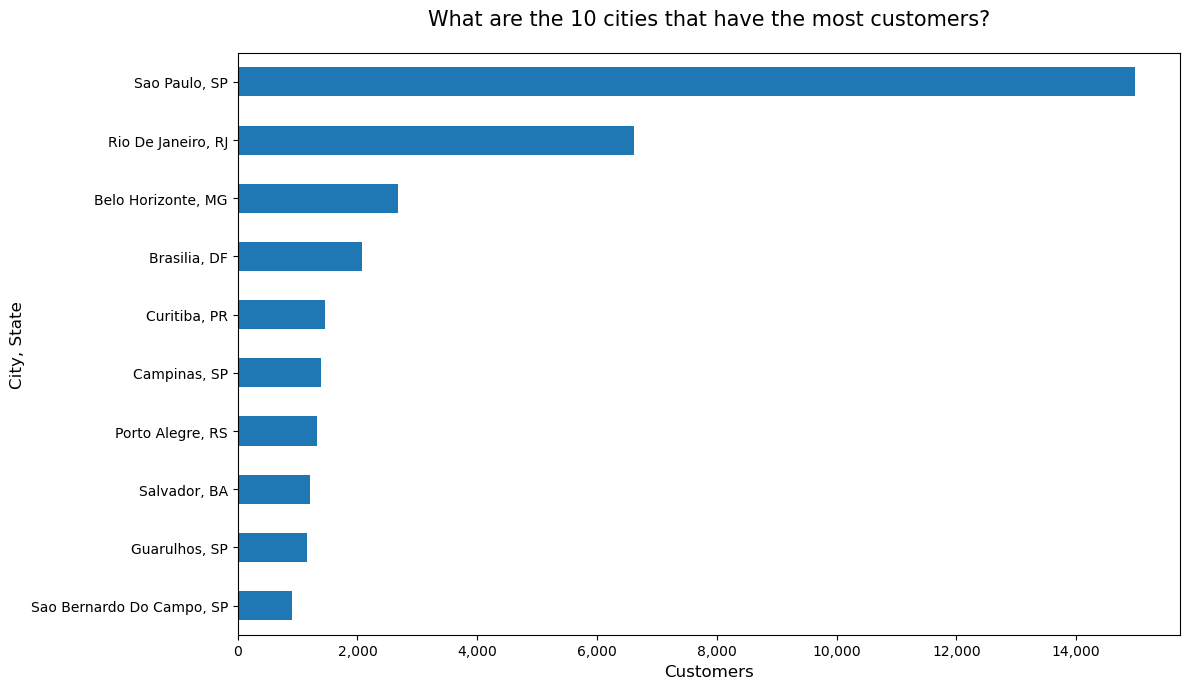

In [12]:
#query7_2
display(df2.head(15)) 
df2['city_state'] = df2['city'] + ", " + df2['state']
df2_top10 = df2.head(10)
plot2=df2_top10.sort_values('customers', ascending=True).plot(
    x='city_state', 
    y='customers', 
    kind='barh', 
    figsize=(12, 7), 
    legend=False
)
plt.ticklabel_format(style='plain', axis='x')
plot2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('What are the 10 cities that have the most customers?', fontsize=15, pad=20)
plt.xlabel('Customers', fontsize=12)
plt.ylabel('City, State', fontsize=12)
plt.tight_layout()
plt.show(plot2)

## Query 8 - Product Category Sales Performance

,product_category,revenue,total_revenue_percent,quantity,total_quantity_percent
0,health beauty,1441248.0,9.10%,9670,8.58%
1,watches gifts,1305542.0,8.24%,5991,5.32%
2,bed bath table,1241682.0,7.84%,11115,9.87%
3,sports leisure,1156656.0,7.30%,8641,7.67%
4,computers accessories,1059272.0,6.69%,7827,6.95%
5,furniture decor,902512.0,5.70%,8334,7.40%
6,housewares,778398.0,4.91%,6964,6.18%
7,cool stuff,719330.0,4.54%,3796,3.37%
8,auto,685384.0,4.33%,4235,3.76%
9,garden tools,584219.0,3.69%,4347,3.86%


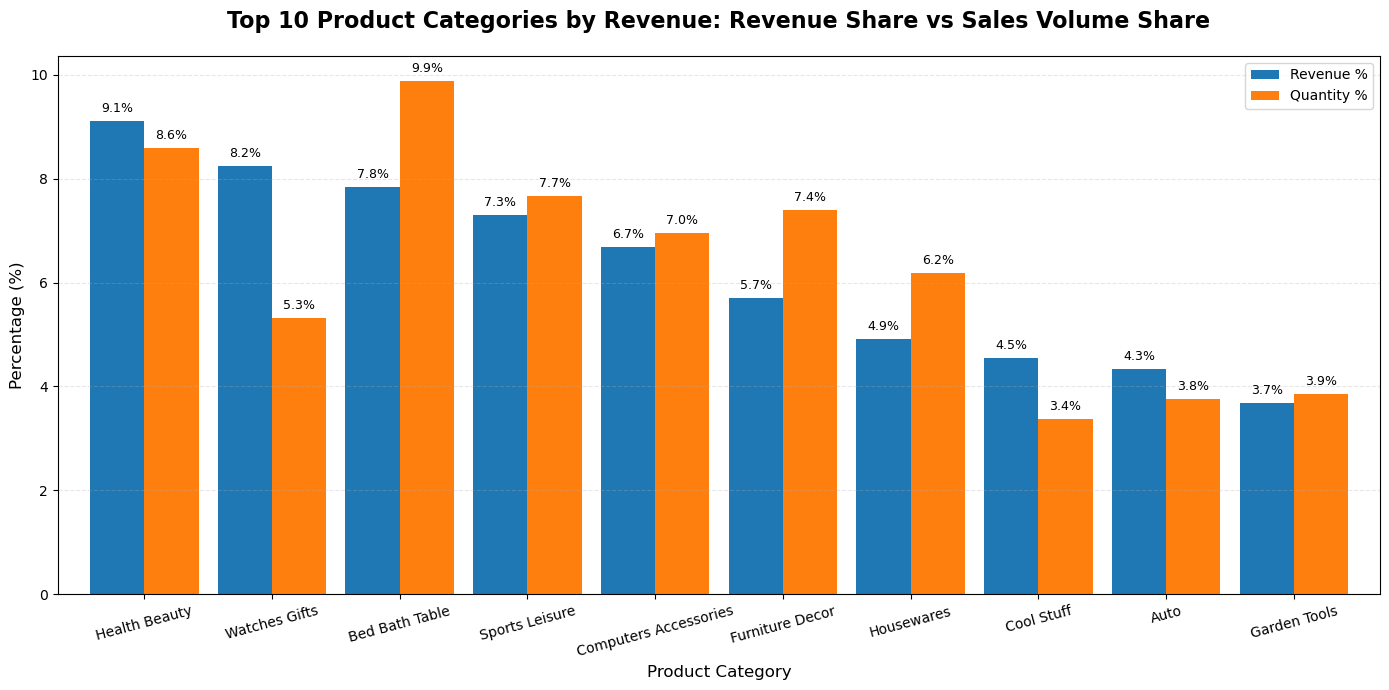

In [25]:
query8 = """
WITH 
items AS(
	SELECT 
		a.order_id,
		a.order_item_id,
		b.product_category_name,
		a.price+a.freight_value AS total_price
	FROM 
		olist_order_items a
	LEFT JOIN olist_products b ON a.product_id = b.product_id)

SELECT
	a.product_category,
    ROUND(a.revenue) revenue,
    CONCAT(ROUND((a.revenue / (SUM(a.revenue) OVER() )) * 100,2),'%%') AS total_revenue_percent,
    a.quantity,
    CONCAT(ROUND((a.quantity / (SUM(a.quantity) OVER() )) * 100,2),'%%') AS total_quantity_percent
FROM
	(SELECT 
		REPLACE((CASE
			WHEN b.product_category_name_english IS NOT NULL then b.product_category_name_english
			ELSE a.product_category_name
		END),"_"," ") AS product_category,
		SUM(a.total_price) revenue,
		COUNT(a.order_item_id) quantity
	FROM
		items a
	LEFT JOIN product_category_name_translation b ON a.product_category_name = b.product_category_name
	GROUP BY product_category
	ORDER BY revenue DESC) a
"""
df = pd.read_sql(query8,engine)
display(df.head(20))

df['total_revenue_percent'] = df['total_revenue_percent'].str.replace('%', '').astype(float)
df['total_quantity_percent'] = df['total_quantity_percent'].str.replace('%', '').astype(float)
df['product_category'] = df['product_category'].str.title()
df_sorted = df.sort_values(by='total_revenue_percent',ascending=False)
df_top10 = df_sorted.head(10)

ax = df_top10.plot(
    x='product_category', 
    y=['total_revenue_percent', 'total_quantity_percent'], 
    kind='bar', 
    figsize=(14, 7),
    width=0.85
)
ax.set_title('Top 10 Product Categories by Revenue: Revenue Share vs Sales Volume Share', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Product Category', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=15, ha='center')
ax.legend(['Revenue %', 'Quantity %'])
ax.grid(axis='y', linestyle='--', alpha=0.3)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

## Query 9 - Reviews Score by Product Category

In [14]:
query9 = """
WITH
rating AS
	(WITH 
	reviewscore AS
	(
	SELECT DISTINCT
	a.order_id,b.product_id,c.product_category_name,d.product_category_name_english,a.review_score,a.review_creation_date
	FROM olist_order_reviews a
	LEFT JOIN olist_order_items b on a.order_id = b.order_id
	LEFT JOIN olist_products c on b.product_id = c.product_id
	LEFT JOIN product_category_name_translation d on c.product_category_name = d.product_category_name)
	SELECT 
		a.*,
		ROW_NUMBER() OVER (
		PARTITION BY a.order_id, a.product_id 
		ORDER BY a.review_creation_date DESC) AS date_order
	FROM 
		reviewscore a
	)

SELECT
	REPLACE(a.product_category_name_english,'_'," ") AS product_category,
    COUNT(a.review_score) AS total_review,
	ROUND(AVG(a.review_score),2) AS avg_review_score,
    CONCAT(ROUND((SUM(IF(a.review_score=5,1,0))/COUNT(a.review_score)) * 100,2),"%%") AS '5/5',
    CONCAT(ROUND((SUM(IF(a.review_score=4,1,0))/COUNT(a.review_score)) * 100,2),"%%") AS '4/5',
    CONCAT(ROUND((SUM(IF(a.review_score=3,1,0))/COUNT(a.review_score)) * 100,2),"%%") AS '3/5',
    CONCAT(ROUND((SUM(IF(a.review_score=2,1,0))/COUNT(a.review_score)) * 100,2),"%%") AS '2/5',
    CONCAT(ROUND((SUM(IF(a.review_score=1,1,0))/COUNT(a.review_score)) * 100,2),"%%") AS '1/5'
FROM
	rating a
WHERE a.date_order = 1
GROUP BY product_category 
ORDER BY total_review DESC;
"""
df = pd.read_sql(query9,engine)
df.head(20)

,product_category,total_review,avg_review_score,5/5,4/5,3/5,2/5,1/5
0,bed bath table,10041,3.92,52.06%,19.52%,10.14%,4.48%,13.80%
1,health beauty,8955,4.17,61.32%,17.97%,7.91%,2.47%,10.34%
2,sports leisure,7806,4.15,60.22%,19.06%,7.33%,2.59%,10.80%
3,computers accessories,6844,4.00,55.06%,19.92%,8.20%,3.51%,13.33%
4,furniture decor,6723,3.98,55.39%,18.28%,8.85%,4.02%,13.46%
5,housewares,5977,4.12,58.74%,18.99%,8.62%,3.23%,10.42%
6,watches gifts,5748,4.05,56.84%,18.82%,8.63%,3.57%,12.14%
7,telephony,4254,3.98,52.47%,21.42%,10.13%,3.95%,12.04%
8,auto,3970,4.07,56.70%,20.58%,7.76%,3.32%,11.64%
9,toys,3946,4.18,61.96%,17.49%,7.63%,2.46%,10.47%


## Query 10 - Logistics and Delivery Performance by Year

In [15]:
query10 = """
SELECT 
	YEAR(a.order_approved_at) year,
	COUNT(a.order_id) AS total_orders_delivered,
    ROUND(AVG(DATEDIFF(a.order_delivered_customer_date, a.order_purchase_timestamp))) AS avg_day_to_deliver,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date,1,0)) * 100,2),"%%") AS on_time_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date, DATEDIFF(a.order_estimated_delivery_date,a.order_delivered_customer_date), NULL))) AS avg_days_before_estimate,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date,1,0)) * 100,2),'%%') AS late_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date, DATEDIFF(a.order_delivered_customer_date, a.order_estimated_delivery_date), NULL))) AS avg_days_past_estimate
    
FROM olist_orders a
WHERE a.order_status = 'delivered' AND YEAR(a.order_approved_at) IS NOT NULL
GROUP BY year
ORDER BY year ASC
"""
df = pd.read_sql(query10,engine)
df

,year,total_orders_delivered,avg_day_to_deliver,on_time_delivery_rate,avg_days_before_estimate,late_delivery_rate,avg_days_past_estimate
0,2016,267,20.0,98.50%,37.0,1.50%,14.0
1,2017,43357,13.0,93.36%,14.0,6.64%,10.0
2,2018,52840,12.0,90.63%,13.0,9.36%,8.0


## Query 11 - Logistics Performance by Product Category

In [16]:
query11="""
WITH 
category_logistic AS
(
SELECT 
	a.*,
	d.product_category_name_english
FROM olist_orders a
LEFT JOIN olist_order_items b ON a.order_id = b.order_id
LEFT JOIN olist_products c ON b.product_id = c.product_id
LEFT JOIN product_category_name_translation d ON c.product_category_name = d.product_category_name
WHERE a.order_status = 'delivered' AND YEAR(a.order_approved_at) IS NOT NULL
)

SELECT
	REPLACE(a.product_category_name_english,'_'," ") AS product_category,
	COUNT(a.order_id) AS total_orders_delivered,
    ROUND(AVG(DATEDIFF(a.order_delivered_customer_date, a.order_purchase_timestamp))) AS avg_day_to_deliver,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date,1,0)) * 100,2),"%%") AS on_time_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date, DATEDIFF(a.order_estimated_delivery_date,a.order_delivered_customer_date), NULL))) AS avg_days_before_estimate,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date,1,0)) * 100,2),'%%') AS late_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date, DATEDIFF(a.order_delivered_customer_date, a.order_estimated_delivery_date), NULL))) AS avg_days_past_estimate
FROM category_logistic a
GROUP BY product_category
ORDER BY total_orders_delivered DESC;
"""
df=pd.read_sql(query11,engine)
df.head(20)

,product_category,total_orders_delivered,avg_day_to_deliver,on_time_delivery_rate,avg_days_before_estimate,late_delivery_rate,avg_days_past_estimate
0,bed bath table,10952,13.0,91.60%,14.0,8.40%,9.0
1,health beauty,9465,12.0,90.95%,14.0,9.05%,8.0
2,sports leisure,8429,12.0,92.57%,14.0,7.41%,9.0
3,furniture decor,8157,13.0,91.57%,14.0,8.43%,9.0
4,computers accessories,7644,13.0,92.22%,14.0,7.77%,9.0
5,housewares,6795,11.0,93.51%,14.0,6.49%,8.0
6,watches gifts,5859,13.0,91.69%,14.0,8.28%,8.0
7,telephony,4428,13.0,91.67%,13.0,8.33%,8.0
8,garden tools,4267,14.0,92.03%,14.0,7.97%,9.0
9,auto,4140,12.0,91.69%,13.0,8.29%,10.0


## Query 12 - Logistics Performance by Geography

In [17]:
query12="""
WITH 
state_logistic AS
(
SELECT 
	a.*,
    b.customer_city,
    b.customer_state
FROM olist_orders a
LEFT JOIN olist_customers b ON a.customer_id = b.customer_id
WHERE a.order_status = 'delivered' AND YEAR(a.order_approved_at) IS NOT NULL
)
SELECT
	a.customer_city AS city, a.customer_state AS state,
	COUNT(a.order_id) AS total_orders_delivered,
    ROUND(AVG(DATEDIFF(a.order_delivered_customer_date, a.order_purchase_timestamp))) AS avg_day_to_deliver,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date,1,0)) * 100,2),"%%") AS on_time_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date <= a.order_estimated_delivery_date, DATEDIFF(a.order_estimated_delivery_date,a.order_delivered_customer_date), NULL))) AS avg_days_before_estimate,
	CONCAT(ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date,1,0)) * 100,2),'%%') AS late_delivery_rate,
    ROUND(AVG(IF(a.order_delivered_customer_date > a.order_estimated_delivery_date, DATEDIFF(a.order_delivered_customer_date, a.order_estimated_delivery_date), NULL))) AS avg_days_past_estimate
FROM state_logistic a
GROUP BY city, state
ORDER BY total_orders_delivered DESC;
"""
df=pd.read_sql(query12,engine)
df.head(20)

,city,state,total_orders_delivered,avg_day_to_deliver,on_time_delivery_rate,avg_days_before_estimate,late_delivery_rate,avg_days_past_estimate
0,sao paulo,SP,15043,8.0,93.74%,12.0,6.26%,6.0
1,rio de janeiro,RJ,6600,15.0,88.18%,17.0,11.82%,12.0
2,belo horizonte,MG,2697,11.0,93.85%,14.0,6.15%,6.0
3,brasilia,DF,2071,13.0,92.90%,13.0,7.10%,6.0
4,curitiba,PR,1489,10.0,95.03%,15.0,4.97%,7.0
5,campinas,SP,1406,10.0,89.83%,11.0,10.17%,6.0
6,porto alegre,RS,1342,16.0,88.15%,15.0,11.77%,9.0
7,salvador,BA,1188,19.0,82.49%,13.0,17.51%,9.0
8,guarulhos,SP,1144,8.0,93.62%,12.0,6.29%,5.0
9,sao bernardo do campo,SP,911,8.0,93.74%,12.0,6.26%,8.0


## Query 13 - Freight Cost Analysis by Product Category

In [18]:
query13="""
WITH
freight_table AS
(
SELECT
	a.order_id,
    a.order_item_id,
	a.product_id,
    c.product_category_name_english AS product_category,
    a.freight_value,
    PERCENT_RANK() OVER (
    PARTITION BY c.product_category_name_english
    ORDER BY freight_value ASC
    ) AS freight_cost_ranking,
    a.price
FROM olist_order_items a
LEFT JOIN olist_products b ON a.product_id = b.product_id
LEFT JOIN product_category_name_translation c ON b.product_category_name = c.product_category_name
),
median_table1 AS
(
SELECT 
	a.product_category,
    MIN(a.freight_value) as median
FROM freight_table a
WHERE a.freight_cost_ranking >=0.5
GROUP BY a.product_category
),
median_table2 AS
(
SELECT 
	a.product_category,
    MAX(a.freight_value) as median
FROM freight_table a
WHERE a.freight_cost_ranking <=0.5
GROUP BY a.product_category
)
SELECT 
	a.product_category,
    SUM(CASE WHEN order_item_id = 1 THEN 1 ELSE 0 END) AS total_orders_delivered,
    COUNT(a.product_category) AS total_items_delivered,
	ROUND((AVG(b.median)+AVG(c.median))/2,2) AS median_freight_value,
    ROUND(AVG(a.freight_value),2) AS avg_freight_value,
	ROUND(AVG(a.price),2) AS avg_price,
    ROUND(AVG(a.freight_value)/AVG(a.price), 2) AS avg_freight_to_price_ratio
FROM freight_table a
LEFT JOIN median_table1 b ON a.product_category = b.product_category
LEFT JOIN median_table2 c ON a.product_category = c.product_category
GROUP BY product_category
ORDER BY total_items_delivered DESC;
"""
df=pd.read_sql(query13,engine)
df.head(20)

,product_category,total_orders_delivered,total_items_delivered,median_freight_value,avg_freight_value,avg_price,avg_freight_to_price_ratio
0,bed_bath_table,9311.0,11115,16.20,18.42,93.30,0.20
1,health_beauty,8796.0,9670,15.80,18.88,130.16,0.15
2,sports_leisure,7681.0,8641,16.28,19.51,114.34,0.17
3,furniture_decor,6355.0,8334,16.40,20.73,87.56,0.24
4,computers_accessories,6660.0,7827,16.00,18.82,116.51,0.16
5,housewares,5829.0,6964,16.75,20.99,90.79,0.23
6,watches_gifts,5601.0,5991,15.82,16.78,201.14,0.08
7,telephony,4182.0,4545,15.11,15.67,71.21,0.22
8,garden_tools,3482.0,4347,17.68,22.77,111.63,0.20
9,auto,3880.0,4235,17.63,21.88,139.96,0.16


## Query 14 - Payment Method Distribution

In [19]:
query14 = """
SELECT
	a.payment_type,
    COUNT(a.payment_type) AS payment_count,
	ROUND(SUM(a.payment_value)) AS total_payment_value,
    CONCAT(ROUND((SUM(a.payment_value)/SUM(SUM(a.payment_value)) OVER()) * 100,2),'%%') AS payment_value_pct
FROM olist_order_payments a
WHERE a.payment_type != 'not_defined'
GROUP BY a.payment_type
ORDER BY payment_count DESC;
"""
df=pd.read_sql(query14,engine)
display(df)

,payment_type,payment_count,total_payment_value,payment_value_pct
0,credit_card,76795,12542084.0,78.34%
1,boleto,19784,2869361.0,17.92%
2,voucher,5775,379437.0,2.37%
3,debit_card,1529,217990.0,1.36%
